# Supplementary Figure S8: Regular Hyperbolic Graphs

Supplementary Figure S8 compares undecorated regular hyperbolic graph patches built from $\{3,7\}$ and $\{3,8\}$ tilings.

This figure includes:

* (a) a $\{3,7\}$ regular hyperbolic graph patch
* (b) a $\{3,8\}$ regular hyperbolic graph patch
* (c) $\{3,7\}$ boundary entropy and scaled $d_{bulk}$ versus region size
* (d) $\{3,8\}$ boundary entropy and scaled $d_{bulk}$ versus region size

## Import Dependencies and Set Parameters

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import os
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "global_figure_settings.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

from __future__ import annotations

import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path("outputs/mplconfig").resolve()))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.transforms import Bbox

import loadconfig as loco
from graph2grav.figure_hashing import save_figure_with_hash

config = loco.reload()
plt.rcParams.update({"figure.dpi": 120})
subfigure_label_fontsize = config["subfigure-label"]["font"]["size"]
COLORS = {
    "bulk": config["graph"]["nodes"]["ancilla"]["outer"]["color"],
    "boundary": config["graph"]["nodes"]["boundary"]["outer"]["color"],
    "selected": config["graph"]["nodes"]["selected_boundary"]["outer"]["color"],
    "selected_fill": config["graph"]["nodes"]["selected_boundary"]["inner"]["color"],
    "positive": config["decorated-figure"]["edges"]["positive"]["color"],
    "negative": config["decorated-figure"]["edges"]["negative"]["color"],
}
FAMILY_COLORS = {
    "{3,7}": config["systems"]["hyperbolic_37"]["color"],
    "{3,8}": config["systems"]["hyperbolic_38"]["color"],
}

import networkx as nx

from graph2grav.analysis import Analysis
from graph2grav.analytic_entropies import periodic_CFT_entropy
from graph2grav.graphs import RegularTilingSpec, generate_regular_patch
from graph2grav.graphs.hyperbolic import isometry_translate_origin_to_w, isometry_translate_w_to_origin
from graph2grav.poincare import hyperbolic_distance

FIGURE_PATH = Path("figures/supplementary-figure_regular-graphs.pdf")
GRAPH_SPECS = [
    RegularTilingSpec(3, 7, depth=3, boundary_shells=1),
    RegularTilingSpec(3, 8, depth=2, boundary_shells=1),
]
COUPLING_TIME = 1.0
PRESQUEEZE = 0.1




## Define Graph and Plotting Helpers

Build regular graph patches, fit boundary entropies, and estimate the scaled bulk distance diagnostic.

In [2]:
def boundary_nodes(graph):
    return sorted(
        [node for node, data in graph.nodes(data=True) if data.get("is_boundary")],
        key=lambda node: graph.nodes[node]["position_in_boundary"],
    )


def tex_symbol(graph):
    return graph.graph["schlafli_symbol"].replace("{", r"\{").replace("}", r"\}")



def lighten_color(color, amount=0.62):
    rgb = np.asarray(mcolors.to_rgb(color), dtype=float)
    return tuple(rgb + (1.0 - rgb) * amount)


def positions(graph):
    return {node: tuple(np.asarray(data["coord"], dtype=float)[:2]) for node, data in graph.nodes(data=True)}


def family_color(graph):
    return FAMILY_COLORS[graph.graph["schlafli_symbol"]]


def plot_regular_graph(ax, graph, label, color):
    pos = positions(graph)
    boundary = set(boundary_nodes(graph))
    bulk = [node for node in graph.nodes if node not in boundary]
    nx.draw_networkx_edges(graph, pos, ax=ax, width=0.55, alpha=0.28, edge_color=color)
    nx.draw_networkx_nodes(graph, pos, nodelist=bulk, ax=ax, node_size=18, node_color=lighten_color(color), linewidths=0)
    nx.draw_networkx_nodes(graph, pos, nodelist=list(boundary), ax=ax, node_size=32, node_color=color, linewidths=0)
    ax.add_patch(plt.Circle((0, 0), 1.0, fill=False, lw=0.8, color=color, alpha=0.45))
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(label)


def coord_as_complex(graph, node):
    coord = np.asarray(graph.nodes[node]["coord"], dtype=float)
    return complex(float(coord[0]), float(coord[1]))


def hyperbolic_geodesic_midpoint(z1, z2):
    if abs(z1 - z2) < 1e-14:
        return z1
    translated_z2 = isometry_translate_w_to_origin(z2, z1)
    radius = abs(translated_z2)
    if radius < 1e-14:
        midpoint_at_origin = 0j
    else:
        midpoint_radius = np.tanh(0.5 * np.arctanh(radius))
        midpoint_at_origin = midpoint_radius * translated_z2 / radius
    return isometry_translate_origin_to_w(midpoint_at_origin, z1)


def boundary_edge_midpoint(graph, left_position):
    boundary = boundary_nodes(graph)
    boundary_length = len(boundary)
    left = boundary[int(left_position) % boundary_length]
    right = boundary[(int(left_position) + 1) % boundary_length]
    return hyperbolic_geodesic_midpoint(coord_as_complex(graph, left), coord_as_complex(graph, right))


def cut_midpoint_distance(graph, region_size):
    boundary_length = len(boundary_nodes(graph))
    region_size = int(region_size)
    if region_size <= 0 or region_size >= boundary_length:
        return np.nan
    left_cut_midpoint = boundary_edge_midpoint(graph, -1)
    right_cut_midpoint = boundary_edge_midpoint(graph, region_size - 1)
    return float(hyperbolic_distance(left_cut_midpoint, right_cut_midpoint))


def scaled_cut_distance(graph, region_sizes, entropies):
    distances = np.asarray([cut_midpoint_distance(graph, size) for size in region_sizes], dtype=float)
    interior = np.isfinite(distances)
    scaled = np.full_like(distances, np.nan, dtype=float)
    if np.count_nonzero(interior) < 2:
        return distances, scaled
    source_min = float(np.nanmin(distances[interior]))
    source_max = float(np.nanmax(distances[interior]))
    target = np.asarray(entropies, dtype=float)[interior]
    target_min = float(np.nanmin(target))
    target_max = float(np.nanmax(target))
    if source_max <= source_min or target_max <= target_min:
        return distances, scaled
    scaled[interior] = target_min + (distances[interior] - source_min) * (target_max - target_min) / (source_max - source_min)
    return distances, scaled


def analyze_graph(graph):
    analysis = Analysis(
        graph,
        couplingtime=COUPLING_TIME,
        global_presqueeze=PRESQUEEZE,
        is_decorated=False,
    )
    full_region_sizes = np.asarray(analysis.region_sizes, dtype=float)
    full_entropies = np.asarray(analysis.boundary_entropies, dtype=float)
    full_entropies[0] = 0.0
    full_entropies[-1] = 0.0
    fit_region_sizes = full_region_sizes[1:-1]
    central_charge, offset = analysis.fit_central_charge()
    fit = periodic_CFT_entropy(
        fit_region_sizes,
        analysis.boundary_length,
        central_charge=central_charge,
        offset=offset,
    )
    cut_distances, scaled_distances = scaled_cut_distance(graph, full_region_sizes, full_entropies)
    return {
        "analysis": analysis,
        "region_sizes": full_region_sizes,
        "entropies": full_entropies,
        "fit_region_sizes": fit_region_sizes,
        "central_charge": central_charge,
        "offset": offset,
        "fit": fit,
        "cut_distances": cut_distances,
        "scaled_cut_distances": scaled_distances,
    }




## Make Figure

Assemble the graph panels and entropy-distance panels, then save the supplementary figure.

/Users/jonathan/miniconda3/envs/ultra/lib/python3.13/site-packages/networkx/drawing/nx_pylab.py:457: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  node_collection = ax.scatter(


Saved figure to figures/supplementary-figure_regular-graphs.pdf. Hash info updated in figures/.hashes.json; history in figures/.hash_history.json. file_hash=8c11f45f18db44c3, data_hash=742006cdc037b3af, size=35823 bytes.


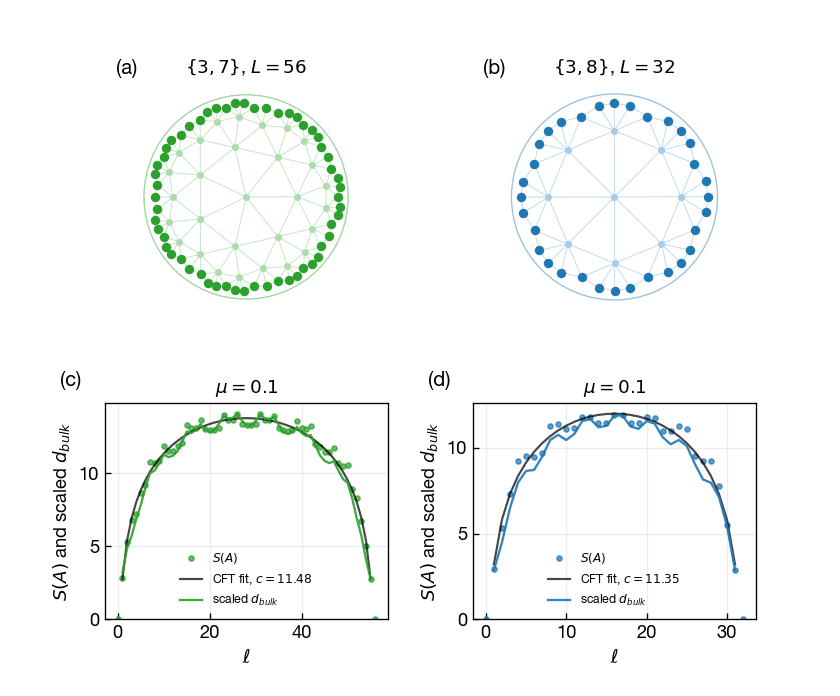

[('{3,7}', 85, 56, np.float64(11.479318549624042)),
 ('{3,8}', 41, 32, np.float64(11.348802564907892))]

In [3]:
graphs = [generate_regular_patch(spec) for spec in GRAPH_SPECS]
results = [analyze_graph(graph) for graph in graphs]

bbox = Bbox.from_bounds(0, 0, 7.0, 5.8)
%config InlineBackend.print_figure_kwargs = {'bbox_inches': bbox}
fig = plt.figure(figsize=(bbox.width, bbox.height))
grid = fig.add_gridspec(2, 2, height_ratios=[1.05, 1.0], hspace=0.42, wspace=0.30)

for index, (graph, result) in enumerate(zip(graphs, results)):
    symbol = tex_symbol(graph)
    label = fr"${symbol}$, $L={len(boundary_nodes(graph))}$"
    ax_graph = fig.add_subplot(grid[0, index])
    color = family_color(graph)
    plot_regular_graph(ax_graph, graph, label, color)
    ax_graph.text(-0.08, 1.04, f"({chr(ord('a') + index)})", transform=ax_graph.transAxes, fontsize=subfigure_label_fontsize)

for index, (graph, result) in enumerate(zip(graphs, results)):
    ax_entropy = fig.add_subplot(grid[1, index])
    color = family_color(graph)
    symbol = tex_symbol(graph)
    entropy_label = r"$S(A)$"
    distance_label = r"scaled $d_{bulk}$"
    ax_entropy.plot(result["region_sizes"], result["entropies"], "o", ms=3.0, alpha=0.7, color=color, label=entropy_label)
    ax_entropy.plot(result["fit_region_sizes"], result["fit"], "-", lw=1.3, color="black", alpha=0.72, label=fr"CFT fit, $c={result['central_charge']:.2f}$")
    distance_mask = np.isfinite(result["scaled_cut_distances"])
    ax_entropy.plot(
        result["region_sizes"][distance_mask],
        result["scaled_cut_distances"][distance_mask],
        "-",
        lw=1.4,
        color=color,
        alpha=0.9,
        label=distance_label,
    )
    ax_entropy.set_title(rf"$\mu={PRESQUEEZE:g}$")
    ax_entropy.set_xlabel(r"$\ell$")
    ax_entropy.set_ylabel(r"$S(A)$ and scaled $d_{bulk}$")
    ax_entropy.grid(alpha=0.22)
    ax_entropy.legend(frameon=False, fontsize=7.3, handlelength=1.8)
    ax_entropy.text(-0.16, 1.08, f"({chr(ord('c') + index)})", transform=ax_entropy.transAxes, fontsize=subfigure_label_fontsize)
    ax_entropy.set_ylim(bottom=0)

save_figure_with_hash(fig, FIGURE_PATH)
plt.show()

[(graph.graph["schlafli_symbol"], graph.number_of_nodes(), len(boundary_nodes(graph)), result["central_charge"]) for graph, result in zip(graphs, results)]

